## Exploring the Impact of AI Adoption on Workforce Dynamics

## INTRODUCTION :

This project focuses on analyzing how Artificial Intelligence adoption is impacting employees, industries, job roles, productivity, salaries, and workforce stability.
The goal is to understand whether AI is replacing jobs, modifying roles, improving productivity, and increasing the need for upskilling.

## BUSINESS PROBLEM STATEMENT:

The rapid advancement of Artificial Intelligence (AI) is transforming industries by
reshaping job roles and workforce dynamics. While AI drives efficiency and innovation,
it also raises concerns about job displacement, skill relevance, and employee wellbeing.
Organizations often lack clear insights into how AI adoption impacts employees across
roles, industries, and experience levels. This project aims to analyze employee data to
understand the overall impact of AI adoption on workforce outcomes and support
informed decision-making.


“Organizations need data-driven insights to understand how AI affects workforce dynamics.”

## OBJECTIVE OF THE PROJECT:

The objective of this project is to perform Exploratory Data Analysis (EDA) to
understand the impact of AI adoption on workforce dynamics. The analysis focuses
on identifying key patterns and relationships to support better organizational
decision-making.


## BUSINESS QUESTIONS
1. How does AI_Adoption_Level influence Job_Status (Replaced, Modified,
Unchanged)?
2. Does Upskilling_Required reduce the likelihood of job replacement across different AI
adoption levels?
3. How does AI_Adoption_Level impact Productivity_Change_% and Job_Satisfaction?
4. How does automation risk vary across industries and job roles?
5. How do education level and work experience vary across AI adoption levels?
6. How does salary change across different AI adoption levels?

## DATA UNDERSTANDING:

In [57]:
#importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
df=pd.read_csv("ai_job_impact.csv")

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            2000 non-null   object 
 1   Age                    2000 non-null   int64  
 2   Gender                 2000 non-null   object 
 3   Education_Level        2000 non-null   object 
 4   Industry               2000 non-null   object 
 5   Job_Role               2000 non-null   object 
 6   Years_Experience       2000 non-null   int64  
 7   AI_Adoption_Level      2000 non-null   object 
 8   Automation_Risk        2000 non-null   object 
 9   Upskilling_Required    2000 non-null   object 
 10  Salary_Before_AI       2000 non-null   int64  
 11  Salary_After_AI        2000 non-null   int64  
 12  Job_Status             2000 non-null   object 
 13  Work_Hours_Per_Week    2000 non-null   int64  
 14  Remote_Work            2000 non-null   object 
 15  Job_

In [60]:
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Education_Level', 'Industry',
       'Job_Role', 'Years_Experience', 'AI_Adoption_Level', 'Automation_Risk',
       'Upskilling_Required', 'Salary_Before_AI', 'Salary_After_AI',
       'Job_Status', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction',
       'Productivity_Change_%'],
      dtype='object')

In [61]:
df.shape

(2000, 17)

In [62]:
df.head(10)

,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03
5,E0006,46,Male,High School,Healthcare,Technician,21,Low,Medium,No,103969,104781,Modified,36,No,6,-19.04
6,E0007,49,Male,PhD,Education,Administrator,24,High,Medium,No,78555,86183,Modified,48,Yes,3,-17.94
7,E0008,57,Male,Bachelor,Finance,Auditor,34,Low,High,No,99479,105776,Unchanged,44,Yes,6,5.51
8,E0009,50,Other,Bachelor,Education,Professor,27,Low,High,Yes,102409,104197,Unchanged,38,No,8,3.71
9,E0010,52,Male,High School,Healthcare,Nurse,27,High,Low,Yes,31016,42699,Unchanged,47,Yes,4,30.67


categorical data are:

employee_id,gender,education_level,industry,job_role,ai_adoption_level,automation_risk,upskilling_required,job_status,remote_work.

real numerical data are:

salary_before_ai,salary_after_ai,Productivity_Change_%

discrete numerical data are:

Age,Years_experience,Work_hours_per_week,job_satisfaction

## WHY AI_ADOPTION_LEVEL IS THE KEY VARIABLE

I considered AI_Adoption_Level as the central variable because it allows comparison of workforce outcomes across Low, Medium, and High AI environments.

Using this variable helps analyze:

Job modification

Productivity

Automation risk

Salary change

Upskilling

Satisfaction

## DATA CLEANING:

In [63]:
# checking is there any null values present in the dataset
df.isnull().sum()

Employee_ID              0
Age                      0
Gender                   0
Education_Level          0
Industry                 0
Job_Role                 0
Years_Experience         0
AI_Adoption_Level        0
Automation_Risk          0
Upskilling_Required      0
Salary_Before_AI         0
Salary_After_AI          0
Job_Status               0
Work_Hours_Per_Week      0
Remote_Work              0
Job_Satisfaction         0
Productivity_Change_%    0
dtype: int64

OBSERVATION:

From the above results we can conclude that above data set is free from null values.

In [64]:
# checking whether the dataset is contains any duplicated values
df.duplicated().sum()

np.int64(0)

OBSERVATIONS:

from the above results we can conclude that the dataset is free from duplicates

In [65]:
df = df.drop(columns=[
    "Employee_ID",
    "Age",
    "Gender",
    "Work_Hours_Per_Week",
    "Remote_Work"
])

In [83]:
df.head()

,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Job_Satisfaction,Productivity_Change_%,Automation_Risk_Score,Experience_Group
0,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,5,-10.64,3,21-30
1,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,6,19.05,1,11-20
2,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,3,17.05,2,21-30
3,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,9,-2.47,2,21-30
4,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,6,7.03,2,NaN


Observation

Columns such as Employee_ID, Age, Gender, Work_Hours_Per_Week, and Remote_Work were removed because they were not directly relevant to the core AI workforce analysis.
This helped simplify the dataset and focus the analysis on variables related to AI adoption, automation risk, productivity, salaries, and workforce outcomes.


## From the above results we can conclude that the above dataset is a cleaned data.

## FEATURE ENGINEERING

In [85]:
df["Salary_Change"] = df["Salary_After_AI"] - df["Salary_Before_AI"]

Salary Change Feature:

To understand the impact of AI on compensation, a new feature was created

This helps in measuring:
    
> Increase or decrease in salary after AI adoption
> Overall financial impact on employees

## DATA VISUALIZATION:

## 1.How does AI_Adoption_Level influence Job_Status (Replaced, Modified,Unchanged)?

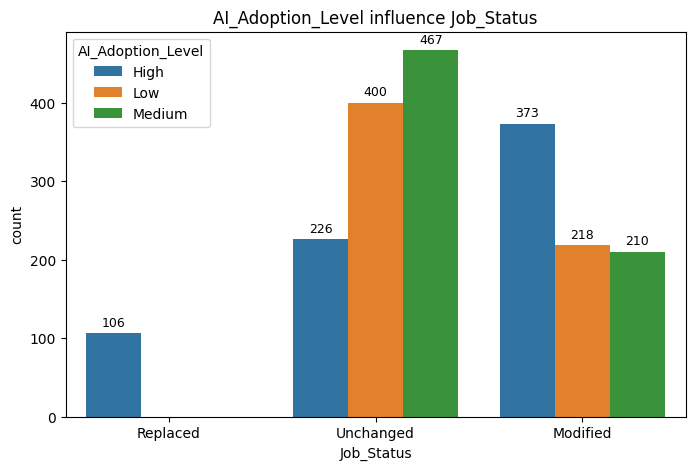

In [73]:
# AI_Adoption_Level vs Job_Status
plt.figure(figsize=(8,5))
ax=sns.countplot(hue="AI_Adoption_Level",x="Job_Status",data=df)
plt.title("AI_Adoption_Level influence Job_Status")
for container in ax.containers:
    ax.bar_label(container,
                 padding=3,
                 fontsize=9)
plt.show()

Observation:

Across AI adoption levels, job modification dominates over complete replacement. High adoption shows the most modified jobs (373), while full replacements remain limited (106). Medium and low adoption levels mostly retain unchanged roles, indicating slower transformation.

insights:

AI adoption is reshaping jobs rather than eliminating them.

High adoption brings more role modifications, with only limited replacements.Medium and low adoption keep most jobs unchanged, showing slower impact.


## 2. Does Upskilling_Required reduce the likelihood of job replacement across different AI

“Can upskilling help employees survive and adapt in AI-driven workplaces?”

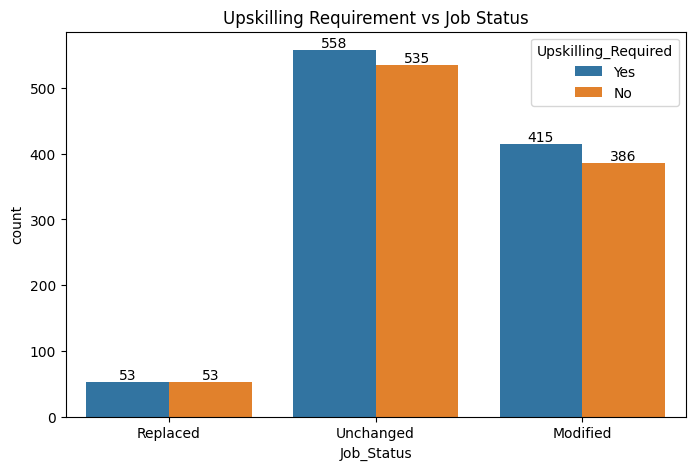

In [74]:
# Upskilling_Required vs Job_Status
plt.figure(figsize=(8,5))

ax = sns.countplot(
    hue='Upskilling_Required',
    x='Job_Status',
    data=df
)

plt.title('Upskilling Requirement vs Job Status')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

 Observation

Replaced jobs are equal in both groups, showing upskilling does not directly reduce replacement.
However, employees requiring upskilling show slightly more modified and unchanged jobs.

 Insight

Upskilling mainly helps employees adapt to changing roles rather than preventing replacement completely.

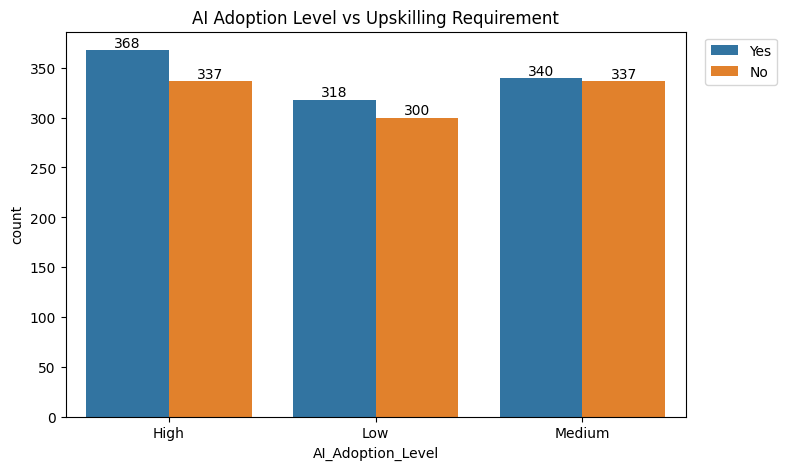

In [75]:
# AI_Adoption_Level vs Upskilling Requirement

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='AI_Adoption_Level',
    hue='Upskilling_Required',
    data=df
)

plt.title('AI Adoption Level vs Upskilling Requirement')

for container in ax.containers:
    ax.bar_label(container)
plt.legend(bbox_to_anchor=(1.02,1),
        loc='upper left')
plt.show()

 Observation

High AI adoption environments show slightly more employees requiring upskilling compared to low and medium AI adoption levels.
Overall, the distribution remains fairly balanced across all categories.

 Insight

As AI adoption increases, the need for employee upskilling also increases slightly.
This suggests continuous learning is important across all AI-driven workplaces.

Final Conclusion

> The analysis shows that upskilling does not significantly reduce job replacement, but it helps employees adapt to changing job roles.
> Higher AI adoption environments also show a slightly greater need for upskilling, highlighting the importance of continuous skill development in AI-driven workplaces.


## 3. How does AI_Adoption_Level impact Productivity_Change_% and Job_Satisfaction?

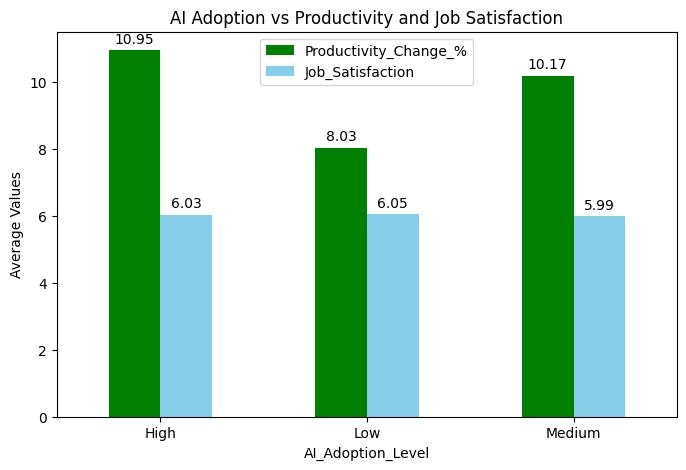

In [76]:
ax=df.groupby("AI_Adoption_Level")[["Productivity_Change_%","Job_Satisfaction"]].mean().plot(
    kind="bar",figsize=(8,5),color=["green","skyblue"])
plt.ylabel("Average Values")
plt.title("AI Adoption vs Productivity and Job Satisfaction")
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.xticks(rotation=0)
plt.show()

Observation

High AI adoption levels show higher productivity changes, while job satisfaction remains relatively stable across categories.

Insight

This suggests that AI adoption improves efficiency without significantly reducing employee satisfaction.

## 4.How does automation risk vary across industries and job roles?

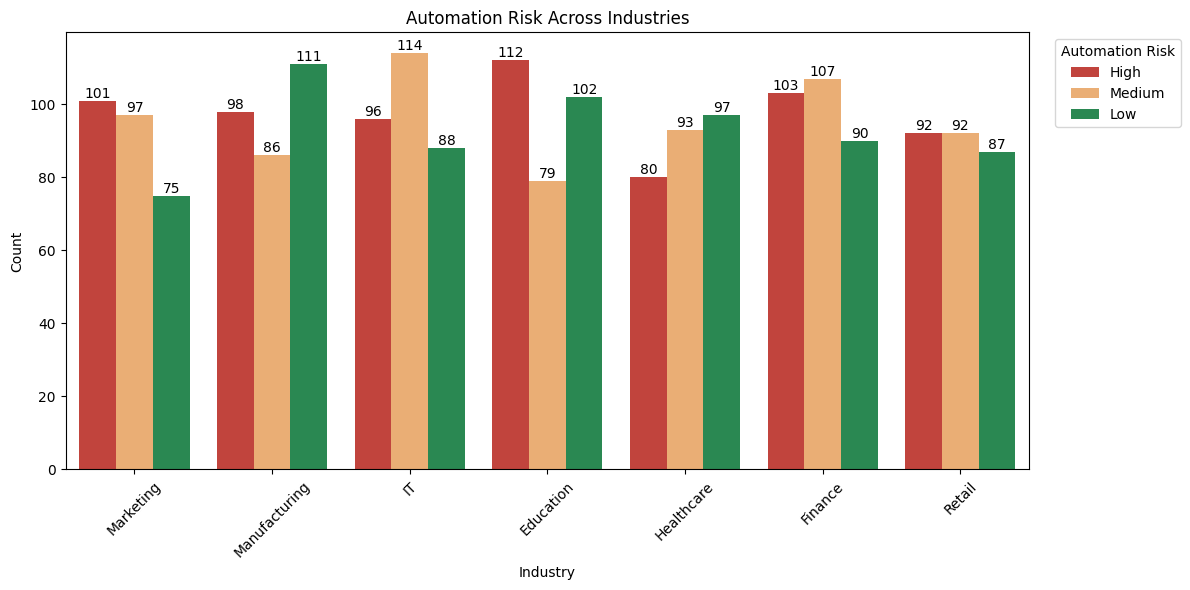

In [77]:
# Automation risk vs industry
plt.figure(figsize=(12,6))

ax=sns.countplot(
    data=df,
    x="Industry",
    hue="Automation_Risk",
    hue_order=["High", "Medium", "Low"],
    palette=["#d73027", "#fdae61", "#1a9850"]
)

plt.title("Automation Risk Across Industries")
plt.xlabel("Industry")
plt.ylabel("Count")
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container)
plt.legend(
    title="Automation Risk",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()

plt.show()

Observation

Education, Finance, and Marketing industries show comparatively higher counts of high automation risk.
Manufacturing and Healthcare display relatively higher low automation risk compared to other industries.

Insight


The analysis suggests that automation exposure varies across industries depending on the nature of tasks and AI integration.
Industries involving repetitive, digital, or process-driven work appear to face greater automation risk.

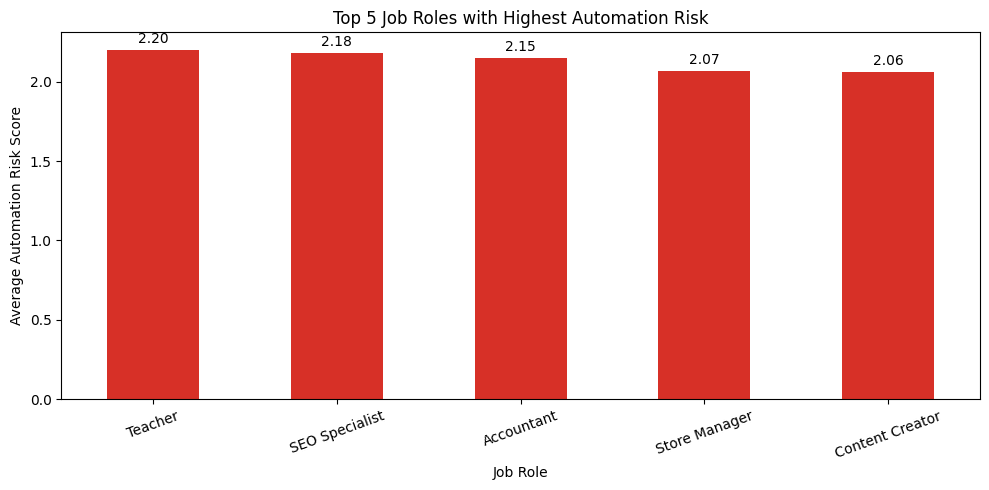

In [78]:
# Automation Risk vs Job role

# Convert Automation Risk into numeric values
risk_map = {"Low":1, "Medium":2, "High":3}

df["Automation_Risk_Score"] = df["Automation_Risk"].map(risk_map)

# Top 5 job roles with highest automation risk
top_roles = (
    df.groupby("Job_Role")["Automation_Risk_Score"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10,5))

ax = top_roles.plot(
    kind="bar",
    color="#d73027"
)

plt.title("Top 5 Job Roles with Highest Automation Risk")
plt.xlabel("Job Role")
plt.ylabel("Average Automation Risk Score")
plt.xticks(rotation=20)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

 Observation

The chart shows that Teacher, SEO Specialist, and Accountant are the job roles with the highest automation risk.
Store Manager and Content Creator also show noticeable exposure to AI-driven automation.

 Insight

This suggests that jobs involving repetitive tasks, content handling, or routine processes are more likely to be impacted by AI technologies.
Employees in these roles may need continuous upskilling to adapt to changing workplace demands.

## 5. How do education level and work experience vary across AI adoption levels?

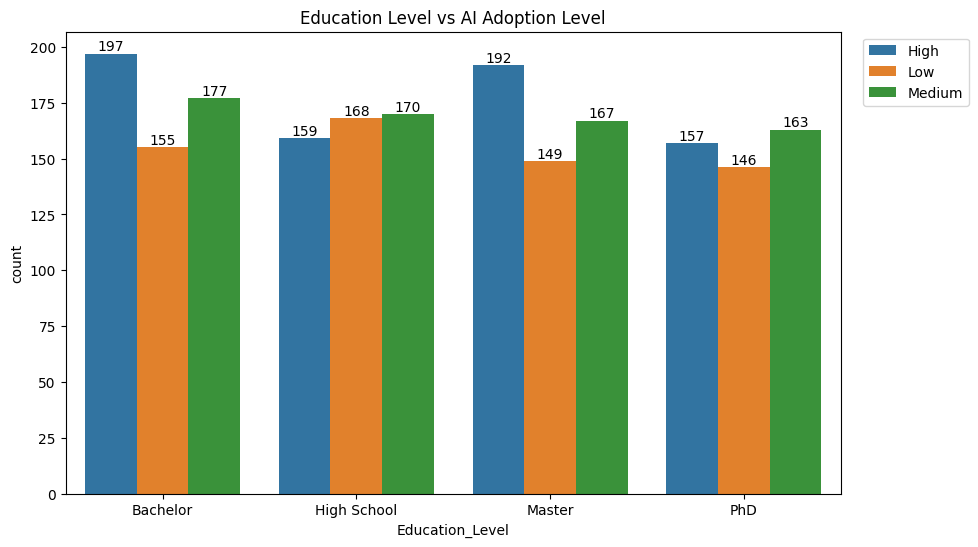

In [79]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    x='Education_Level',
    hue='AI_Adoption_Level',
    data=df
)

plt.title('Education Level vs AI Adoption Level')

for container in ax.containers:
    ax.bar_label(container)
plt.legend(bbox_to_anchor=(1.02,1),
        loc='upper left')
plt.show()

 Observation

Employees with Bachelor’s and Master’s degrees show higher participation in High AI Adoption environments compared to other education groups.
Employees with lower educational qualifications are more commonly distributed across Low and Medium AI adoption levels.

 Insight

The analysis suggests that higher educational qualifications are associated with greater participation in AI-driven workplaces.
This indicates that education may support employee adaptability and readiness in technologically evolving environments.

In [80]:
## Years of Experience vs AI Adoption
df['Experience_Group'] = pd.cut(
    df['Years_Experience'],
    bins=[0,10,20,30,40],
    labels=['0-10','11-20','21-30','31-40']
)

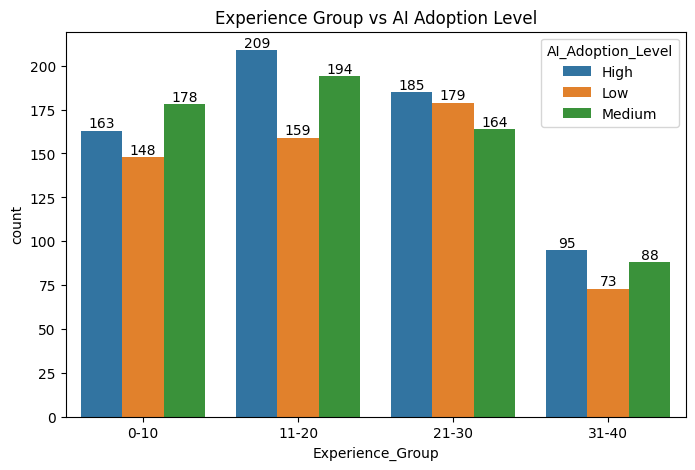

In [81]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Experience_Group',
    hue='AI_Adoption_Level',
    data=df
)

plt.title('Experience Group vs AI Adoption Level')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Observation

Employees with 11–20 years of experience show the highest participation in High AI Adoption environments.
Other experience groups are also distributed across Low, Medium, and High AI adoption categories.

Insight

The analysis suggests that work experience influences employee participation in AI-driven workplaces.
Mid-level experienced employees appear more actively involved in high AI adoption environments due to a balance of expertise and adaptability.

## 6.How does salary change across different AI adoption levels?

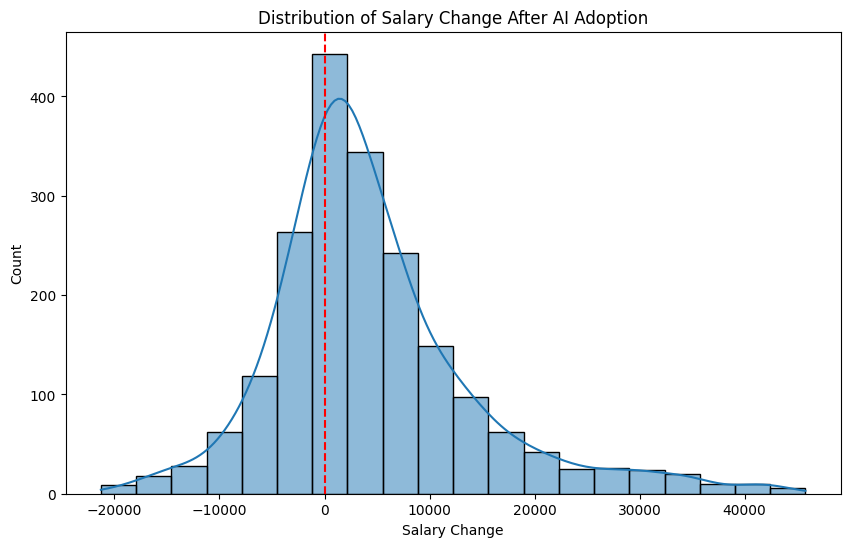

In [86]:
plt.figure(figsize=(10,6))
sns.histplot(df["Salary_Change"], bins=20, kde=True)

plt.title("Distribution of Salary Change After AI Adoption")
plt.xlabel("Salary Change")
plt.ylabel("Count")

plt.axvline(0, color="red", linestyle="--")  # zero change reference line
plt.show()

Observation

The histogram shows the distribution of salary change after AI adoption, centered around zero. Most employees experienced small positive or negative changes, with the highest frequency near the center. The curve is slightly right‑skewed, meaning a larger portion of employees saw increases in salary, while fewer experienced significant decreases. The red dashed line at zero highlights the neutral point where salary remained unchanged.

Insights

Majority of employees benefited from AI adoption, as the distribution leans toward positive salary changes.

Salary growth is uneven — while most increases are modest, a few employees gained substantial raises (up to ₹40,000 range).

Negative salary changes exist, indicating that some roles may have been partially automated or restructured.

Overall, the data suggests AI adoption correlates with salary improvement, reinforcing that AI tends to enhance value rather than reduce compensation.

## Key Findings


> AI adoption impacts job roles more than it directly replaces employees, with most jobs being modified or unchanged.

> Higher AI adoption environments show increased productivity and slightly higher salary growth.

> Automation risk is higher in repetitive and process-oriented job roles such as Teachers, SEO Specialists, and Accountants.

> Employees with higher education levels (Bachelor’s and Master’s) are more represented in high AI adoption environments.

> Mid-level experienced employees (11–20 years) show the highest participation in high AI adoption workplaces.

## Business Insights
>AI is transforming jobs rather than eliminating them, indicating a shift toward role modification.

>Organizations adopting AI tend to reward employees with higher salaries and productivity improvements.

>Workforce vulnerability to automation depends on job type, not just industry.

>Upskilling and continuous learning are key factors for employee survival in AI-driven environments.

>Education and experience both play a role in employee adaptability to AI changes.

## Problems Faced
>Handling multiple categorical variables (Industry, Job Role, Education) made visualization complex.

>Choosing the right plots to represent both numerical and categorical relationships was challenging.

>Interpreting automation risk across multiple dimensions required careful grouping.

>Ensuring clarity while avoiding overloaded graphs was difficult.

##  How I Solved Them

>Reduced complexity by using grouped and summarized visualizations (Top 5 analysis, averages).

>Used different plot types (countplot, barplot, lineplot) based on data type.

>Focused only on key business questions instead of plotting every variable.

>Simplified analysis by breaking large questions into smaller sub-questions.

## What I Learned
>AI adoption significantly reshapes workforce structure and job roles.

>Data visualization is more effective when focused on business questions rather than all variables.

>Interpreting data is more important than just plotting graphs.

>Workforce adaptability depends on education, experience, and job nature.

## Improvements
>We can use more advanced models to predict automation risk more accurately.

>If time-based data is available, we can analyze how AI impact changes over time.

>We can improve feature engineering to get deeper insights into salary and productivity trends.

>We can use tools like Power BI or Tableau to create interactive dashboards for better visualization and storytelling.